In [11]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/cortespaolalejandra-dotcom/EstadisticaVerano2026/refs/heads/main/StudentPerformance/StudentPerformance_Student_Performance.csv")
df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [12]:
X=df["Hours_Studied"] #Variable independiente
Y=df["Performance_Index"] #Variable dependiente

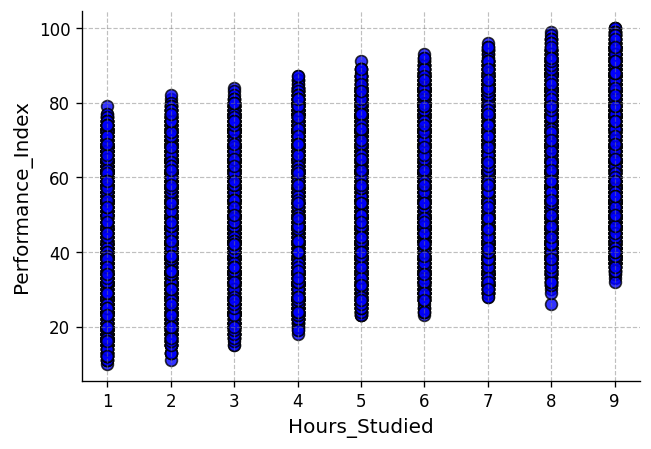

In [22]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

3. **¿Los datos soportan la suposición de linealidad?**

Sí, en el gráfico podemos observar que la suposición de linealidad se cumple, ya que muestra una relación lineal positiva entre las horas de estudio y el índice de desempeño. A medida que aumentan las horas dedicadas al estudio, los valores del rendimiento tienden a incrementarse de manera aproximadamente lineal.

In [24]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.3737
valor_p:  0.0000


El coeficiente de correlación es $r=0.3737$, este valor indica que la correlación es fuerte, dado que está muy cerca de 1. Además, el que sea negativa, implica que aumentar las ausencias ($X$) disminuye el salario ($Y$).

In [25]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [26]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  13.97%


Con coeficiente de determinación de $$r^2=0.1397$$ indica que con las ausencias estoy justificando en un $13.97\%$ la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

In [27]:
modelo.params

,0
const,41.379175
Hours_Studied,2.773063


La ecuación de la recta es:

$$
\hat{y}=41.379175+2.773063X
$$

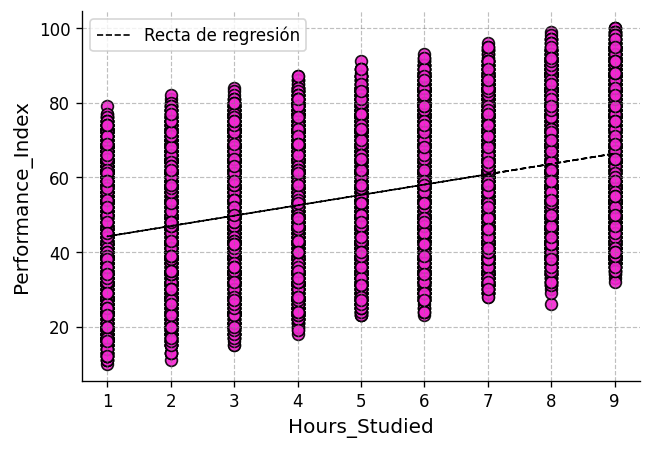

In [28]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

 **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$


In [29]:
modelo.conf_int(alpha=0.05)

,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


El verdadero $b_0$ está entre $40.620341$ y $42.138008$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $2.638143$ y $2.907983$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de hours studied.

In [30]:
residuales = modelo.resid

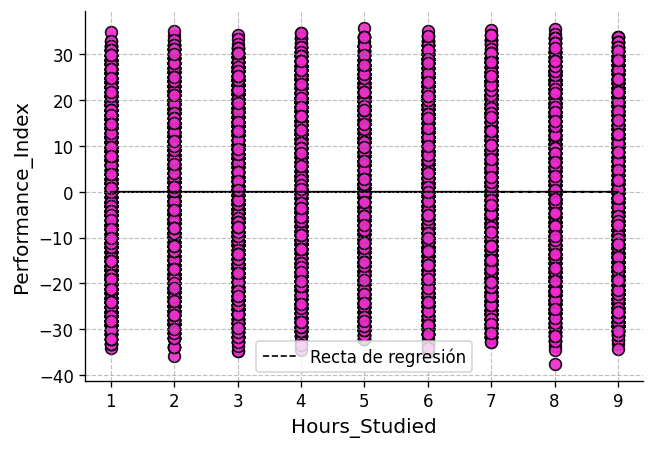

In [31]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que sí, porque muestra una relación entre los puntos y la recta
+ Normalidad: Sí cumple con la normalidad, porque estan mas cerca de la recta
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque hay mayor disperción en los puntos
+ Independencia: Sí cumple, porque son diferentes personas.

valor-p (Shapiro) = 2.3269507843403982e-45


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


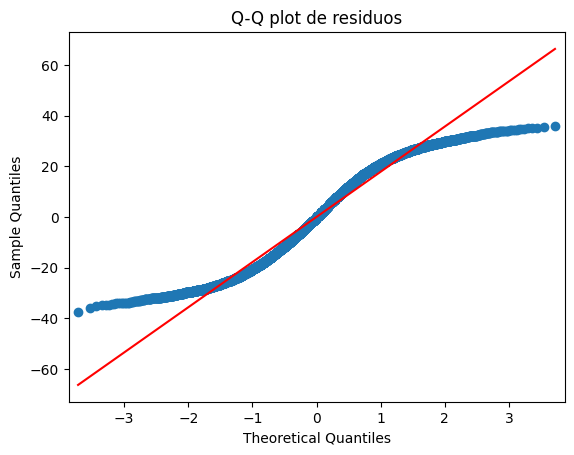

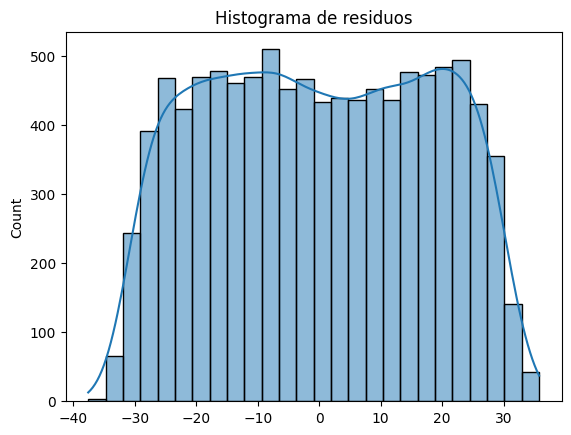

In [32]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#test de Shapiro-Wilk
#H0=Hay normalidad
#H1=No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [33]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.9742



In [35]:
# mínimo hours studied: 1
# máximo hours studied: 9

# interpolar, valores de x entre 1 y 9

# interpolar
y_5 = modelo.predict([1, 5])
y_2 = modelo.predict([1, 2])

print(f"Para x = 5, y =  {y_5[0]: 0.4f}")
print(f"Para x = 2, y =  {y_2[0]: 0.4f}")

Para x = 5, y =   55.2445
Para x = 2, y =   46.9253


In [36]:
df["calificación estimada"] = y_calculada.round()
df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample Question_Papers_Practiced,Performance_Index,calificación estimada
0,7,99,Yes,9,1,91.0,61.0
1,4,82,No,4,2,65.0,52.0
2,8,51,Yes,7,2,45.0,64.0
3,5,52,Yes,5,2,36.0,55.0
4,7,75,No,8,5,66.0,61.0
...,...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0,44.0
9996,7,64,Yes,8,5,58.0,61.0
9997,6,83,Yes,8,5,74.0,58.0
9998,9,97,Yes,7,0,95.0,66.0


In [37]:
# mínimo hours studied: 1
# máximo hours studied: 9

# Extrapolar, valores de x que no estén entre 1 y 9

y_8 = modelo.predict([[1, 8]])

print(f"Para x = 8, y =  {y_8[0]: 0.4f}")

Para x = 8, y =   63.5637


In [38]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''Performance_Index ~ Hours_Studied''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Hours_Studied,1.0,5.155178e+05,515517.816522,1623.181225,0.0
Residual,9998.0,3.175337e+06,317.597203,NaN,NaN
